<a href="https://colab.research.google.com/github/najwasuparna/MultiClassEyeDisease-Classification/blob/main/EyeDisease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Perbandingan Kinerja Arsitektur CNN - MobileNetV2,
ResNet50V2, dan InceptionV3 pada Klasifikasi Multi-
Kelas Citra Medis Penyakit Mata
---
NAJWA HANDARIA SUPARNA / A11.2024.16039

In [ ]:
# Konek ke GDrive kita
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
!ls "/content/gdrive/MyDrive/PEMBELAJARAN MESIN/PROJECT UAS NAJWA 16039/dataset"

cataract  diabetic_retinopathy	glaucoma  normal


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50V2, InceptionV3
import matplotlib.pyplot as plt
import random
import cv2

# **MENAMPILKAN JUMLAH DATA PER-KELAS**

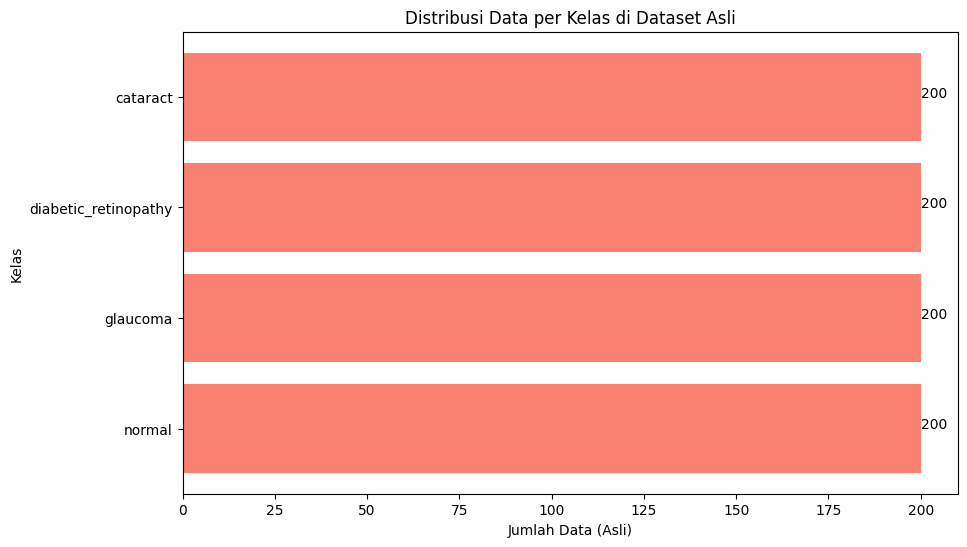

In [ ]:
# The original data directory
original_data_dir = "/content/gdrive/MyDrive/PEMBELAJARAN MESIN/PROJECT UAS NAJWA 16039/dataset"

# Dictionary to store class counts
class_counts_original = {}

# Iterate through each class directory
for class_name in os.listdir(original_data_dir):
    class_path = os.path.join(original_data_dir, class_name)
    if os.path.isdir(class_path):
        # Count files in the directory (assuming all files are images)
        num_images = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
        class_counts_original[class_name] = num_images

# Prepare data for plotting
class_names_original_ordered = sorted(class_counts_original.keys())
counts_original_ordered = [class_counts_original[name] for name in class_names_original_ordered]

# Create the horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(class_names_original_ordered, counts_original_ordered, color='salmon')

# Add counts at the end of each bar
for index, value in enumerate(counts_original_ordered):
    plt.text(value, index, str(value))

plt.xlabel('Jumlah Data (Asli)')
plt.ylabel('Kelas')
plt.title('Distribusi Data per Kelas di Dataset Asli')
plt.gca().invert_yaxis() # To display the first class at the top
plt.show()

# **MENAMPILKAN 4 DATA SECARA ACAK PADA PER-KELAS**

Menampilkan 3 data acak dari masing-masing kelas dari: /content/gdrive/MyDrive/PEMBELAJARAN MESIN/PROJECT UAS NAJWA 16039/dataset


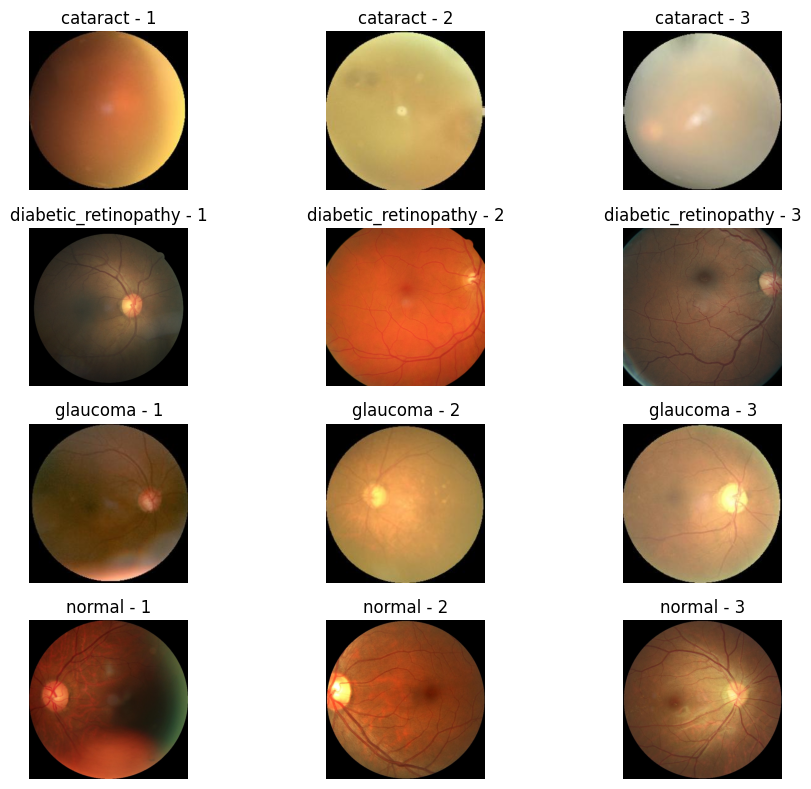

In [ ]:


DATA_DIR = '/content/gdrive/MyDrive/PEMBELAJARAN MESIN/PROJECT UAS NAJWA 16039/dataset'

print(f"Menampilkan 3 data acak dari masing-masing kelas dari: {DATA_DIR}")

class_names = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
class_names.sort()

plt.figure(figsize=(10, 2 * len(class_names)))

for i, class_name in enumerate(class_names):
    class_path = os.path.join(DATA_DIR, class_name)
    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if len(image_files) < 3:
        print(f"Warning: Kelas '{class_name}' hanya memiliki {len(image_files)} gambar. Menampilkan semua yang tersedia.")
        selected_images = image_files
    else:
        selected_images = random.sample(image_files, 3)

    for j, img_file in enumerate(selected_images):
        img_path = os.path.join(class_path, img_file)
        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: Gagal memuat gambar {img_path}. Melanjutkan ke gambar berikutnya.")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax = plt.subplot(len(class_names), 3, i * 3 + j + 1)
        plt.imshow(img)
        plt.title(f"{class_name} - {j+1}")
        plt.axis("off")

plt.tight_layout()
plt.show()

# **MENDEFINISIKAN DAN SPLIT DATA TRAIN DAN VALIDASI**

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 4

In [ ]:
# 1. Inisialisasi ImageDataGenerator
datagen = ImageDataGenerator(
    rescale=1./255, # Normalisasi data
    validation_split=0.2 # Potong 20% otomatis untuk validasi
)

In [ ]:
# Generator Data Asli untuk Training
train_ds = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 640 images belonging to 4 classes.


In [ ]:
# Generator Data Asli untuk Validasi
val_ds = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 160 images belonging to 4 classes.


# **MENDEFINISIKAN METRICS DAN LOSS FUNCTION**

In [ ]:
# untuk 3 kelas atau lebih
LOSS_FUNCTION = 'categorical_crossentropy'
METRICS = ['accuracy']

# MENDEFINISIKAN MODEL/ARSITEKTUR YANG DIGUNAKAN

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50V2, InceptionV3

# 2. Fungsi Praktis Pembuat Model

def buat_model(architecture_name):
    name_lower = architecture_name.lower()

    # Inisialisasi Base Model

    if name_lower == 'mobilenetv2':
        base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

    elif name_lower == 'resnet50v2':
        base_model = ResNet50V2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

    elif name_lower == 'inceptionv3':
        base_model = InceptionV3(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

    else:
        raise ValueError("Arsitektur tidak dikenali. Pilih: 'mobilenetv2', 'resnet50v2', atau 'inceptionv3'.")

    # Freeze arsitektur utama (Transfer Learning dasar)
    base_model.trainable = False

    # Susun arsitektur lengkap
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.2), # Opsional: Mencegah overfitting pada dense layer
        layers.Dense(NUM_CLASSES, activation='softmax') # Softmax untuk 3 kelas atau lebih
    ], name=f"Model_{architecture_name}")

    # Compile model
    model.compile(optimizer='adam', loss=LOSS_FUNCTION, metrics=METRICS)
    return model

# **INISIALISASI MODEL**

In [ ]:
# 3. Inisialisasi Kedua Model
model_mobile = buat_model('mobilenetv2')
model_resnet = buat_model('resnet50v2')
model_inception = buat_model('inceptionv3')

# **TRAINING MODELNYA**

In [ ]:
# ==========================================================
# PROSES TRAINING 3 MODEL DENGAN LOOPING
# ==========================================================

# Daftar nama arsitektur yang ingin digunakan
arsitektur_list = ['mobilenetv2', 'resnet50v2', 'inceptionv3']

# Dictionary kosong untuk menyimpan hasil riwayat (history) training tiap model
histories = {}
models_dict = {}

# Proses looping training secara otomatis
for arch in arsitektur_list:
    print(f"\n=======================================================")
    print(f" MULAI MEMBANGUN & MELATIH MODEL: {arch.upper()}")
    print(f"=======================================================")

    # 1. Memanggil fungsi praktis milikmu untuk membuat model
    model_aktif = buat_model(arch)

    # 2. Proses Training menggunakan data matamu (10 Epochs sesuai acuan dosen)
    history = model_aktif.fit(
        train_ds,
        epochs=30,
        validation_data=val_ds
    )

    # 3. Simpan hasil training ke dalam dictionary agar bisa dipakai buat grafik nanti
    histories[arch] = history
    models_dict[arch] = model_aktif

    print(f"=======================================================")
    print(f" SELESAI MELATIH MODEL: {arch.upper()}")
    print(f"=======================================================\n")

print("🎉 Selesai! Ketiga model CNN berhasil dilatih 100%!")

# ==========================================================
# TAMBAHAN: Ekstrak ke variabel satuan agar sinkron dengan cell lamamu
# ==========================================================
model_mobile = models_dict['mobilenetv2']
model_resnet = models_dict['resnet50v2']
model_inception = models_dict['inceptionv3']

history_mobilenet = histories['mobilenetv2']
history_resnet = histories['resnet50v2']
history_inception = histories['inceptionv3']


 MULAI MEMBANGUN & MELATIH MODEL: MOBILENETV2
Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 516ms/step - accuracy: 0.4594 - loss: 1.2094 - val_accuracy: 0.7063 - val_loss: 0.7129
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 221ms/step - accuracy: 0.7469 - loss: 0.6593 - val_accuracy: 0.8313 - val_loss: 0.5287
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 216ms/step - accuracy: 0.8078 - loss: 0.5214 - val_accuracy: 0.8562 - val_loss: 0.4224
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 225ms/step - accuracy: 0.8453 - loss: 0.4605 - val_accuracy: 0.8813 - val_loss: 0.3894
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 207ms/step - accuracy: 0.8562 - loss: 0.3981 - val_accuracy: 0.8938 - val_loss: 0.3433
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 202ms/step - accuracy: 0.8625 - loss: 0.3604 - val_accuracy: 0.8938 - val_loss: 0.3256
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 237ms/step - accuracy: 0.8938 - loss: 0.3225 - val_accuracy: 0.9125 - val_loss: 0.3047
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 201ms/step - ac

# **MENAMPILKAN GRAFIK PLOT AKURASI DAN LOSS**

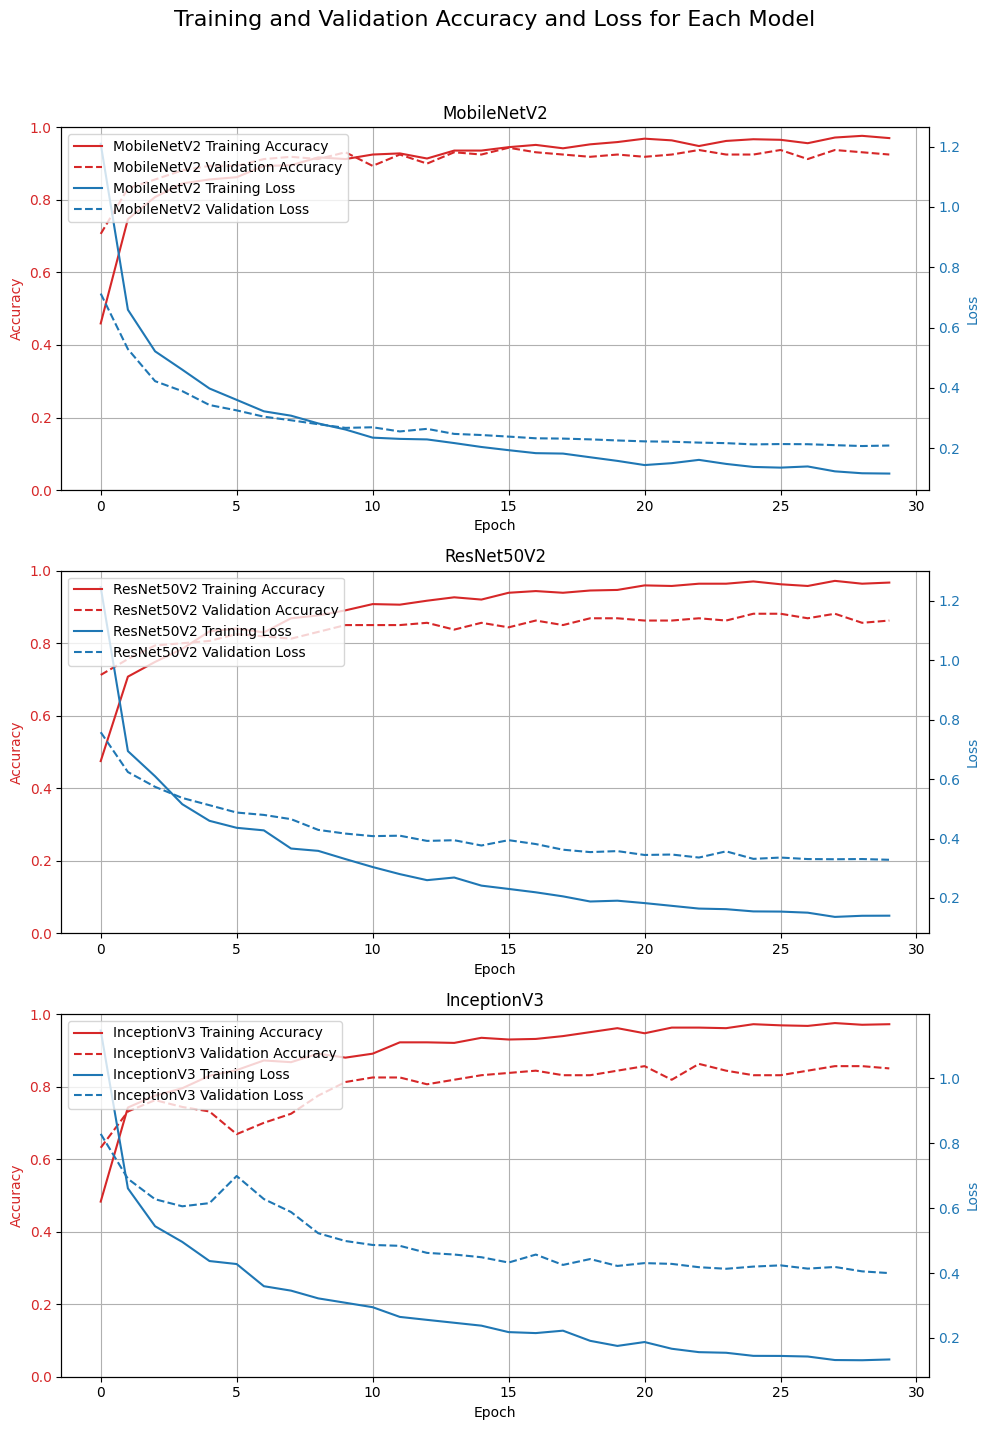

In [ ]:
# 1. Sesuaikan pengambilan data riwayat dari hasil loop
histories_grafik = {
    'MobileNetV2': histories['mobilenetv2'],
    'ResNet50V2': histories['resnet50v2'],
    'InceptionV3': histories['inceptionv3']
}

import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 15))
fig.suptitle('Training and Validation Accuracy and Loss for Each Model', fontsize=16)

# 2. Lakukan plotting menggunakan histories_grafik
for i, (model_name, history) in enumerate(histories_grafik.items()):
    ax1 = axes[i]
    color_acc = 'tab:red'
    color_loss = 'tab:blue'

    # Plot Akurasi
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy', color=color_acc)
    ax1.plot(history.history['accuracy'], color=color_acc, label=f'{model_name} Training Accuracy')
    ax1.plot(history.history['val_accuracy'], color=color_acc, linestyle='--', label=f'{model_name} Validation Accuracy')
    ax1.tick_params(axis='y', labelcolor=color_acc)
    ax1.set_ylim([0, 1])

    # Buat sumbu Y kedua untuk Loss
    ax2 = ax1.twinx()
    ax2.set_ylabel('Loss', color=color_loss)
    ax2.plot(history.history['loss'], color=color_loss, label=f'{model_name} Training Loss')
    ax2.plot(history.history['val_loss'], color=color_loss, linestyle='--', label=f'{model_name} Validation Loss')
    ax2.tick_params(axis='y', labelcolor=color_loss)

    ax1.set_title(f'{model_name}')
    ax1.grid(True)

    # Gabungkan legenda dari kedua sumbu
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## **MENAMPILKAN CONFUSION MATRIX**


 EVALUASI MODEL: MOBILENETV2
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step


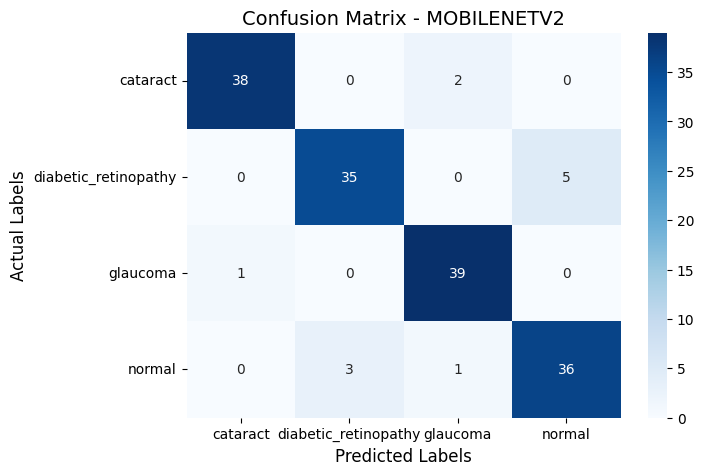


======= CLASSIFICATION REPORT: MOBILENETV2 =======
                      precision    recall  f1-score   support

            cataract       0.97      0.95      0.96        40
diabetic_retinopathy       0.92      0.88      0.90        40
            glaucoma       0.93      0.97      0.95        40
              normal       0.88      0.90      0.89        40

            accuracy                           0.93       160
           macro avg       0.93      0.92      0.92       160
        weighted avg       0.93      0.93      0.92       160



 EVALUASI MODEL: RESNET50V2
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step


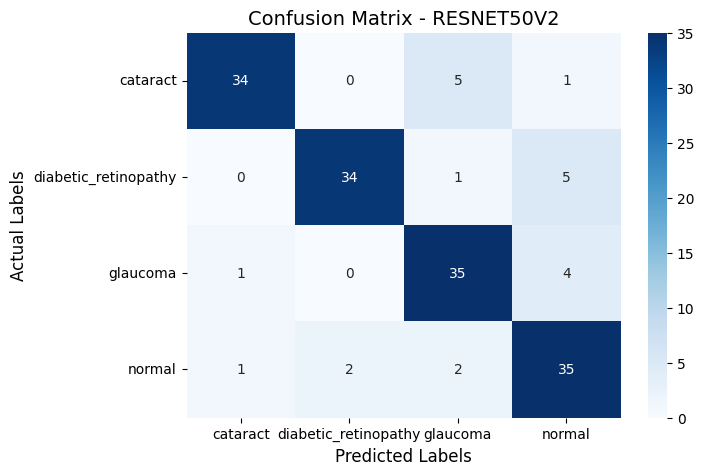


======= CLASSIFICATION REPORT: RESNET50V2 =======
                      precision    recall  f1-score   support

            cataract       0.94      0.85      0.89        40
diabetic_retinopathy       0.94      0.85      0.89        40
            glaucoma       0.81      0.88      0.84        40
              normal       0.78      0.88      0.82        40

            accuracy                           0.86       160
           macro avg       0.87      0.86      0.86       160
        weighted avg       0.87      0.86      0.86       160



 EVALUASI MODEL: INCEPTIONV3
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step


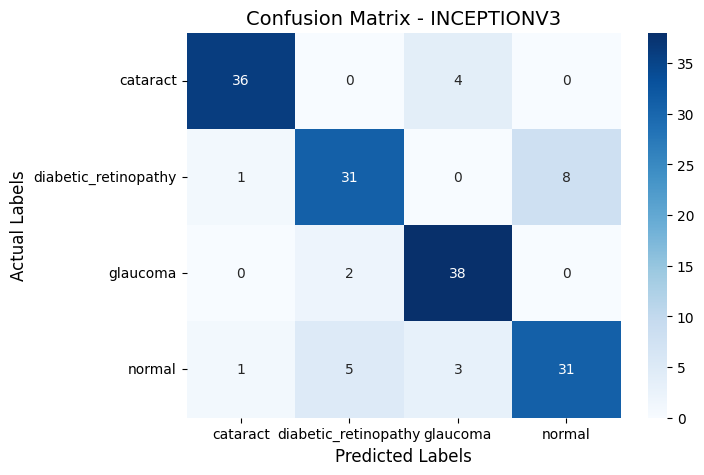


======= CLASSIFICATION REPORT: INCEPTIONV3 =======
                      precision    recall  f1-score   support

            cataract       0.95      0.90      0.92        40
diabetic_retinopathy       0.82      0.78      0.79        40
            glaucoma       0.84      0.95      0.89        40
              normal       0.79      0.78      0.78        40

            accuracy                           0.85       160
           macro avg       0.85      0.85      0.85       160
        weighted avg       0.85      0.85      0.85       160




In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# =====================================================================
# 1. PENTING: Kunci Data Validasi (Matikan Shuffle)
# =====================================================================
val_ds.reset()
val_ds.shuffle = False
val_ds.index_array = None

# Ambil label asli dari generator (Label Sebenarnya)
y_true = val_ds.classes
# Ambil nama kelas untuk penanda di grafik (Cataract, dll)
class_labels = list(val_ds.class_indices.keys())

# =====================================================================
# 2. LOOPING EVALUASI UNTUK SEMUA MODEL
# =====================================================================
for model_name, model_obj in models_dict.items():
    print(f"\n" + "="*60)
    print(f" EVALUASI MODEL: {model_name.upper()}")
    print("="*60)

    # A. Proses Prediksi Gambar
    predictions = model_obj.predict(val_ds, verbose=1)

    # B. Ambil Indeks Kelas dengan Probabilitas Tertinggi (Tebakan Model)
    y_pred = np.argmax(predictions, axis=1)

    # C. Membuat Grafik Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels,
                yticklabels=class_labels)

    plt.title(f'Confusion Matrix - {model_name.upper()}', fontsize=14)
    plt.ylabel('Actual Labels', fontsize=12)
    plt.xlabel('Predicted Labels', fontsize=12)
    plt.show()

    # D. Menampilkan Classification Report (Precision, Recall, F1-Score)
    print(f"\n======= CLASSIFICATION REPORT: {model_name.upper()} =======")
    print(classification_report(y_true, y_pred, target_names=class_labels))
    print("="*60 + "\n")

# Classification Report



In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# =====================================================================
# 1. PENTING: Kunci Urutan Data Uji (Matikan Shuffle)
# =====================================================================
val_ds.reset()
val_ds.shuffle = False
val_ds.index_array = None

# Ambil kunci jawaban asli dan nama kelas langsung dari generator dataset
y_true_fixed = val_ds.classes
class_names_fixed = list(val_ds.class_indices.keys())

# =====================================================================
# 2. Ambil Objek Model yang Asli dari Hasil Looping Training Sebelumnya
# =====================================================================
models_to_evaluate = {
    'MobileNetV2': models_dict['mobilenetv2'],
    'ResNet50V2': models_dict['resnet50v2'],
    'InceptionV3': models_dict['inceptionv3']
}

# =====================================================================
# 3. Looping untuk Membuat Laporan Performa Masing-masing Model
# =====================================================================
for model_name, model in models_to_evaluate.items():
    print(f"\n" + "="*50)
    print(f"--- Classification Report for {model_name} ---")
    print("="*50)

    # Proses prediksi dengan progress bar (verbose=1)
    y_pred_probs = model.predict(val_ds, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Generate dan print classification report yang akurat
    print(classification_report(y_true_fixed, y_pred, target_names=class_names_fixed))


--- Classification Report for MobileNetV2 ---
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step
                      precision    recall  f1-score   support

            cataract       0.97      0.95      0.96        40
diabetic_retinopathy       0.92      0.88      0.90        40
            glaucoma       0.93      0.97      0.95        40
              normal       0.88      0.90      0.89        40

            accuracy                           0.93       160
           macro avg       0.93      0.92      0.92       160
        weighted avg       0.93      0.93      0.92       160


--- Classification Report for ResNet50V2 ---
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step
                      precision    recall  f1-score   support

            cataract       0.94      0.85      0.89        40
diabetic_retinopathy       0.94      0.85      0.89        40
            glaucoma       0.81      0.88      0.84        40
              normal       0.78      0.88      0.82        40

            accura